<a href="https://colab.research.google.com/github/i-malur/bootcamp-data-analytics-mod9/blob/main/m%C3%B3dulo_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Testes de hipóteses em Python

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Qui-quadrado para associações e variáveis categóricas

In [ ]:
from tabulate import tabulate

In [ ]:
t = [
    ['Male', 'Car'],
    ['Male', 'Car'],
    ['Male', 'Motorcycle'],
    ['Female', 'Car'],
    ['Female', 'Bike']]

In [ ]:
print(tabulate(t, headers=['Gender', 'Vehicle'], tablefmt = 'fancy_grid', stralign='center', numalign='center', floatfmt='.2f'))

╒══════════╤════════════╕
│  Gender  │  Vehicle   │
╞══════════╪════════════╡
│   Male   │    Car     │
├──────────┼────────────┤
│   Male   │    Car     │
├──────────┼────────────┤
│   Male   │ Motorcycle │
├──────────┼────────────┤
│  Female  │    Car     │
├──────────┼────────────┤
│  Female  │    Bike    │
╘══════════╧════════════╛


### 1. Criando tabela de contingência

In [ ]:
# tabela de frequência
print(tabulate([['Male', 9, 18, 28], ['Female', 5, 8, 15]],
               headers=['Car', 'Motorcycle', 'Bike'],
               tablefmt='fancy_grid', stralign='center',
               numalign='center', floatfmt='.2f'))

╒════════╤═══════╤══════════════╤════════╕
│        │  Car  │  Motorcycle  │  Bike  │
╞════════╪═══════╪══════════════╪════════╡
│  Male  │   9   │      18      │   28   │
├────────┼───────┼──────────────┼────────┤
│ Female │   5   │      8       │   15   │
╘════════╧═══════╧══════════════╧════════╛


<Axes: >

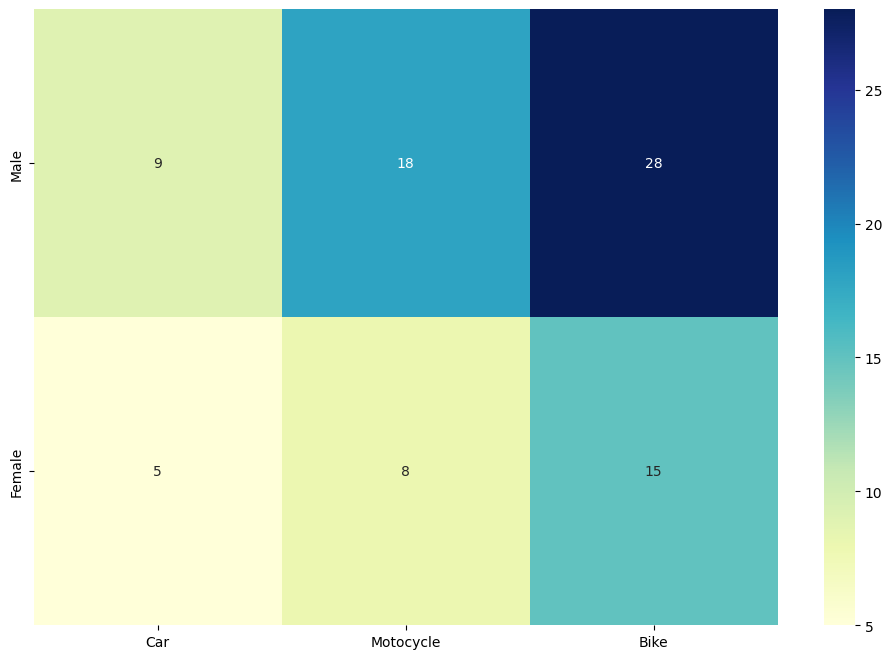

In [ ]:
# tabela com cores

table = [[9, 18, 28], [5, 8, 15]]

plt.figure(figsize=(12,8))
x_axis_labels = ['Car', 'Motocycle', 'Bike']
y_axis_labels = ['Male', 'Female']

sns.heatmap(table, annot=True, cmap='YlGnBu', xticklabels=x_axis_labels, yticklabels=y_axis_labels)

### 2. Formulando hipóteses
H0: As variáveis não tem grau de associação.

HA: As variáveis possuem grau de associação.

Nível de significância (alpha) = 0.05 (5%).

### 3. Rodando o teste

In [ ]:
from scipy.stats import chi2_contingency
from scipy.stats import chi2

estatistica, pvalor, df, expected = chi2_contingency(table)

print('Estatística do teste: ', estatistica)
print('P valor: ', pvalor)
print('Grau de liberdade: ', df)
print('Valor crítico esperado: ', expected)



alpha = 0.05
if pvalor <= alpha:
  print('\n\n p-valor menor ou igual que alpha. Dependentes (rejeita H0)')
else:
  print('\n\n p-valor maior que alpha. Independentes (não rejeita H0)')


Estatística do teste:  0.1522189604415519
P valor:  0.9267147440706386
Grau de liberdade:  2
Valor crítico esperado:  [[ 9.27710843 17.22891566 28.4939759 ]
 [ 4.72289157  8.77108434 14.5060241 ]]


 p-valor maior que alpha. Independentes (não rejeita H0)


### Teste ANOVA

Usando o teste ANOVA para média de idade de diferentes regiões de clientes de uma determinada rede de farmácias

In [ ]:
# gerando os dados
import scipy.stats as stats

np.random.seed(12)

regioes = ['sul', 'sudeste', 'centro_oeste', 'norte', 'nordeste']

# gerando dados aleatórios com o Python
consum_reg = np.random.choice(a = regioes,
                               p = [0.05, 0.15, 0.25, 0.05, 0.5],
                               size = 1000)

# diferentes idades
consum_idade = stats.poisson.rvs(loc = 18,
                                 mu = 30,
                                 size = 1000)


In [ ]:
# agrupando os dados por região
consum_frame = pd.DataFrame({'reg': consum_reg,
                             'idade': consum_idade})

grupos = consum_frame.groupby('reg').groups

# extraíndo a idade de cada um dos grupos
sul = consum_idade[grupos['sul']]
sudeste = consum_idade[grupos['sudeste']]
centro_oeste = consum_idade[grupos['centro_oeste']]
norte = consum_idade[grupos['norte']]
nordeste = consum_idade[grupos['nordeste']]

# ANOVA - teste f
stats.f_oneway(sul, sudeste, centro_oeste, norte, nordeste)

F_onewayResult(statistic=np.float64(1.7744689357329695), pvalue=np.float64(0.13173183201930463))

Como a hipótese nula do testes é de que não há diferença de médias entre os grupos, como o p-valor é maior de 0.05, não podemos rejeitar H0.

Então, não há diferença entre os grupos estísticamente diferentes.

Ou seja: não há diferença de idade entre os grupos, as idades são parecidas entre os grupos.

# Teste KS

/tmp/ipykernel_806/358873475.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(rvs).set_title('Exemplo: Distribuição Normal')


Text(0.5, 1.0, 'Exemplo: Distribuição Normal')

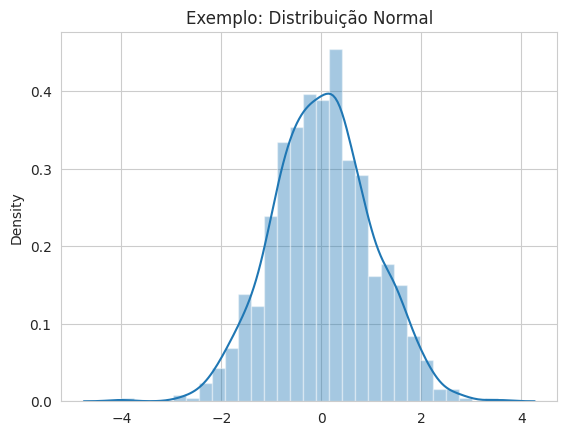

In [ ]:
# Gerando 1000 pontos de uma distribuição normal
rvs = stats.norm.rvs(size=1000)
sns.set_style('whitegrid')

sns.distplot(rvs).set_title('Exemplo: Distribuição Normal')

Rodando um teste KS para comparar os dados gerados com uma distribuição normal com o teste KS.

In [ ]:
stats.kstest(rvs=rvs, cdf='norm')

KstestResult(statistic=np.float64(0.021585641652678095), pvalue=np.float64(0.7314658378406946), statistic_location=np.float64(-1.1770606907923395), statistic_sign=np.int8(-1))

A hipótese nula do teste é de que a distribuição dos dados segue a mesma distribuição de referência.

Sendo assim, como o p-valor é maior que 0.05, temos para um nível de significância de 5%, não podemos rejeitar a H0.

### Rodando o mesmo teste com a variável idade gerada com a distribuição de poisson no teste anterior

/tmp/ipykernel_806/3531339225.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(consum_idade).set_title('Exemplo: Distribuição idade. poisson')


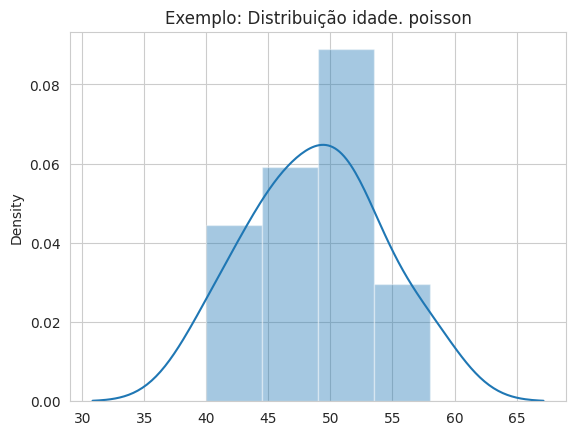

In [ ]:
# gerando variável idade com poisson
consum_idade = stats.poisson.rvs(loc=18,
                                 mu=30,
                                 size=15)

sns.distplot(consum_idade).set_title('Exemplo: Distribuição idade. poisson')
plt.show()

In [ ]:
stats.kstest(rvs=consum_idade, cdf='norm')

KstestResult(statistic=np.float64(1.0), pvalue=np.float64(0.0), statistic_location=np.int64(40), statistic_sign=np.int8(-1))

A hipótese nula do teste é de que a distribuição dos dados segue a mesma distribuição de referência.

Sendo assim, como o p-valor é menor que 0.05, temos para um nível de significância de 5%, podemos rejeitar a H0. O dado não segue uma distribuição normal pelo teste.

# QQ PLOTS

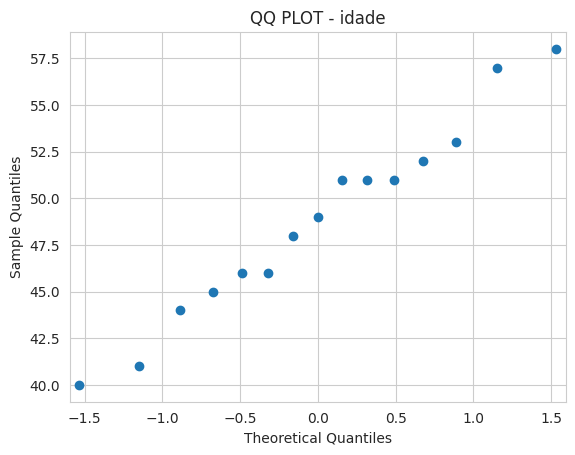

In [ ]:
import statsmodels.api as sm

sm.qqplot(consum_idade)
plt.title('QQ PLOT - idade')
plt.show()

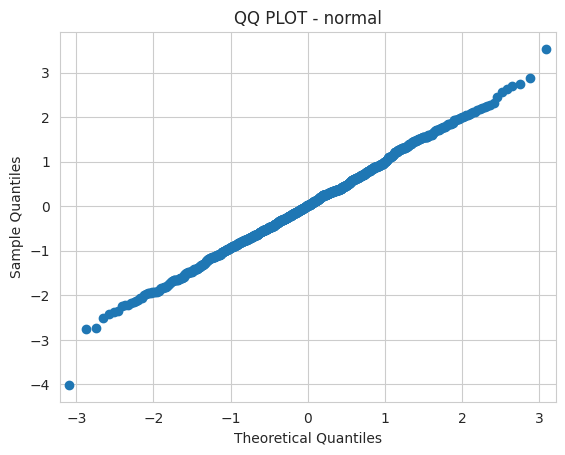

In [ ]:
sm.qqplot(rvs)
plt.title('QQ PLOT - normal')
plt.show()